In [66]:
import pandas as pd
import numpy as np

In [67]:
df = pd.read_csv(r"C:\Users\rmstn\final_project\Geunsu\data\가맹점_정보(통합).csv", encoding='cp949')
df

,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
0,202301,41135,41135510,100470,Q13,음식,커피/음료,A,57,1,0,0,1,0,0,0,0,0,1,0
1,202301,41135,41135510,100470,R07,학문/교육,입시학원,A,84,1,1,0,1,0,0,0,0,0,0,1
2,202301,41135,41135680,101678,O03,여가/오락,일반스포츠,A,1,1,0,1,0,1,0,0,1,0,0,0
3,202301,41135,41135680,101678,O03,여가/오락,일반스포츠,NaN,32,1,0,0,0,1,0,0,1,0,0,0
4,202301,41135,41135680,101678,O03,여가/오락,일반스포츠,신규,0,1,0,1,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2130066,202512,41135,41135670,99971,F02,생활서비스,미용서비스,A,6,1,0,0,1,0,1,0,0,0,0,0
2130067,202512,41135,41135670,99971,F06,생활서비스,세탁/가사서비스,A,199,1,0,0,0,0,0,0,0,0,0,1
2130068,202512,41135,41135670,99971,Q03,음식,닭/오리요리,A,166,1,0,0,0,0,0,0,0,0,0,1
2130069,202512,41135,41135670,99986,R03,학문/교육,기타교육,A,12,1,0,0,1,0,0,1,0,0,0,0


# 전처리 작업

## 1.1 전처리 작업(컬럼 확인)

#### 1.1.1 데이터 타입 확인

In [68]:
df.dtypes

ta_ym              int64
cty_rgn_no         int64
admi_cty_no        int64
blk_cd             int64
card_tpbuz_cd        str
card_tpbuz_nm_1      str
card_tpbuz_nm_2      str
sale                 str
mm_cnt             int64
mer_cnt            int64
fran_cnt           int64
open_cnt           int64
stop_cnt           int64
close_cnt          int64
open_11_cnt        int64
open_12_23_cnt     int64
open_24_35_cnt     int64
open_36_47_cnt     int64
open_48_59_cnt     int64
open_60_cnt        int64
dtype: object

#### 1.1.2 컬럼 정제

In [69]:
df['ta_ym'] = pd.to_datetime(df['ta_ym'], format='%Y%m')
df['cty_rgn_no'] = df['cty_rgn_no'].astype(str)
df['admi_cty_no'] = df['admi_cty_no'].astype(str)
df['blk_cd'] = df['blk_cd'].astype(str)

# 변환 결과 확인
print(df.dtypes)

ta_ym              datetime64[us]
cty_rgn_no                    str
admi_cty_no                   str
blk_cd                        str
card_tpbuz_cd                 str
card_tpbuz_nm_1               str
card_tpbuz_nm_2               str
sale                          str
mm_cnt                      int64
mer_cnt                     int64
fran_cnt                    int64
open_cnt                    int64
stop_cnt                    int64
close_cnt                   int64
open_11_cnt                 int64
open_12_23_cnt              int64
open_24_35_cnt              int64
open_36_47_cnt              int64
open_48_59_cnt              int64
open_60_cnt                 int64
dtype: object


## 1.2 전처리 작업(컬럼별 결측치 및 이상치 확인)

#### 중복값 확인

In [70]:
key_cols = ['ta_ym', 'cty_rgn_no', 'admi_cty_no', 'blk_cd',
            'card_tpbuz_cd', 'card_tpbuz_nm_1', 'card_tpbuz_nm_2', 'sale']

# 중복 개수
dup_count = df.duplicated(subset=key_cols).sum()
print(f"키 컬럼 기준 중복 행 개수: {dup_count:,}")
print(f"전체 행 개수: {len(df):,}")
print(f"중복 비율: {dup_count / len(df) * 100:.4f}%")

키 컬럼 기준 중복 행 개수: 0
전체 행 개수: 2,130,071
중복 비율: 0.0000%


#### 1.2.1 기준년월 컬럼

In [71]:
# ta_ym 유효성 검증 (datetime 변환 후 월 범위 및 결측 확인)
invalid_month = df[~df['ta_ym'].dt.month.isin(range(1, 13))]
print(f"월 범위 오류: {len(invalid_month)}건")
print(f"NULL 수: {df['ta_ym'].isnull().sum()}건")
print(f"범위: {df['ta_ym'].min()} ~ {df['ta_ym'].max()}")

월 범위 오류: 0건
NULL 수: 0건
범위: 2023-01-01 00:00:00 ~ 2025-12-01 00:00:00


#### 1.2.2 시군구 코드 컬럼

In [72]:
col = df['cty_rgn_no'].astype(str)

print(f"5자리 아닌 값: {len(df[col.str.len() != 5])}건")
print(f"NULL 수: {df['cty_rgn_no'].isnull().sum()}건")
print(f"고유 코드 수: {df['cty_rgn_no'].nunique()}개")
df["cty_rgn_no"].value_counts()

5자리 아닌 값: 0건
NULL 수: 0건
고유 코드 수: 3개


cty_rgn_no
41135    1064991
41133     534650
41131     530430
Name: count, dtype: int64

#### 1.2.3 행정동 코드

In [73]:
col = df['admi_cty_no'].astype(str)

print(f"NULL 수: {df['admi_cty_no'].isnull().sum()}건")
print(f"8자리 아닌 값: {len(df[col.str.len() != 8])}건")
print(f"고유 코드 수: {df['admi_cty_no'].nunique()}개")

NULL 수: 0건
8자리 아닌 값: 0건
고유 코드 수: 50개


#### 1.2.4 블록 코드

In [74]:
col = df['blk_cd'].astype(str)

print(f"NULL 수: {df['blk_cd'].isnull().sum()}건")
print(f"공백 값: {len(df[col.str.strip() == ''])}건")
print(f"고유 블록코드 수: {df['blk_cd'].nunique()}개")

NULL 수: 0건


공백 값: 0건
고유 블록코드 수: 5442개


#### 1.2.5 카드사_업종분류코드

In [75]:
print(f"NULL 수: {df['card_tpbuz_cd'].isnull().sum()}건")
print(f"공백 값: {len(df[df['card_tpbuz_cd'].astype(str).str.strip() == ''])}건")
print(f"고유 코드 수: {df['card_tpbuz_cd'].nunique()}개")

NULL 수: 0건
공백 값: 0건
고유 코드 수: 83개


#### 1.2.6 카드사_업종대분류명

In [76]:
print(f"NULL 수: {df['card_tpbuz_nm_1'].isnull().sum()}건")
print(f"고유 대분류명 수: {df['card_tpbuz_nm_1'].nunique()}개")
print(df['card_tpbuz_nm_1'].value_counts())

NULL 수: 0건
고유 대분류명 수: 9개
card_tpbuz_nm_1
소매/유통       662539
음식          636418
생활서비스       319161
학문/교육       185292
의료/건강       141450
여가/오락        97602
공공/기업/단체     69436
미디어/통신       13274
공연/전시         4899
Name: count, dtype: int64


#### 1.2.7 카드사_업종중분류명

In [77]:
print(f"NULL 수: {df['card_tpbuz_nm_2'].isnull().sum()}건")
print(f"공백 값: {len(df[df['card_tpbuz_nm_2'].astype(str).str.strip() == ''])}건")
print(f"고유 중분류명 수: {df['card_tpbuz_nm_2'].nunique()}개")
print(df['card_tpbuz_nm_2'].value_counts().head(20))

NULL 수: 0건
공백 값: 0건
고유 중분류명 수: 83개
card_tpbuz_nm_2
한식            163070
의복/의류         110323
종합소매점          93353
커피/음료          86216
음/식료품소매        81810
미용서비스          80055
인테리어/가정용품      78380
제조/도매          59029
차량관리/서비스       54268
광고/인쇄/인화       49371
기업             48996
의약/의료품         48658
닭/오리요리         46705
고기요리           46367
가전제품           44568
분식             44025
유아교육           43060
일식/수산물         42943
제과/제빵/떡/케익     41854
간이주점           40022
Name: count, dtype: int64


#### 1.2.8 매출구간

NULL 수: 387860건
공백 값: 0건


<bound method Axes.set of <Axes: title={'center': '매출구간 분포'}, xlabel='매출구간', ylabel='건수'>>

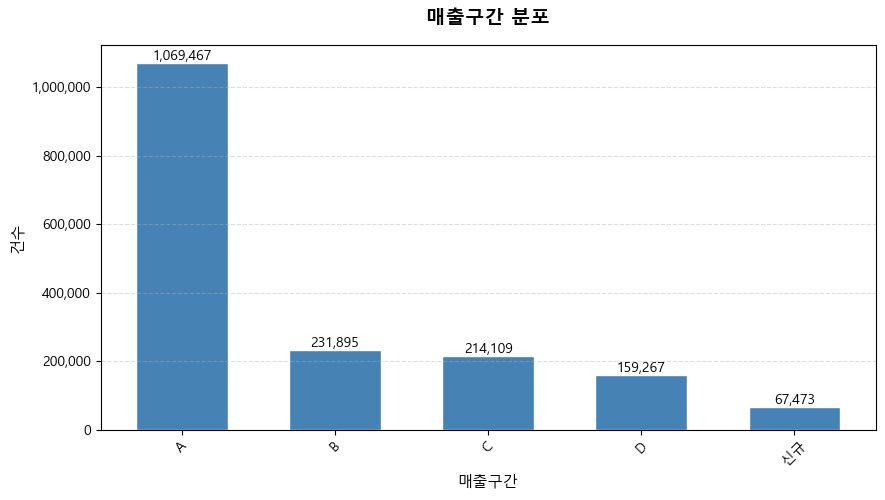

In [78]:
print(f"NULL 수: {df['sale'].isnull().sum()}건")
print(f"공백 값: {len(df[df['sale'].astype(str).str.strip() == ''])}건")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

sale_counts = df['sale'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(sale_counts.index, sale_counts.values, color='steelblue', edgecolor='white', width=0.6)

# 막대 위 숫자 표시
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

ax.set_title('매출구간 분포', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('매출구간', fontsize=11)
ax.set_ylabel('건수', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set

- 신규: 해당 기준년월 내 가맹점 신설
- A:3억 이하
- B:3억 초과-5억 이하 
- C:5억 초과-10억 이하
- D:10억 초과~30억 이하
- null: 30억 초과 또는 국세청 정보 내 연매출 규모 미존재 건

In [79]:
# sale 결측치 처리: null = 30억 초과 또는 국세청 미등록 → 'E' 구간으로 채움
df['sale'] = df['sale'].fillna('E')
print(f"처리 후 NULL 수: {df['sale'].isnull().sum()}건")
print(df['sale'].value_counts().sort_index())

처리 후 NULL 수: 0건
sale
A     1069467
B      231895
C      214109
D      159267
E      387860
신규      67473
Name: count, dtype: int64


#### 1.2.9 영업개월수

In [80]:
col = pd.to_numeric(df['mm_cnt'], errors='coerce')

print(f"NULL 수: {df['mm_cnt'].isnull().sum()}건")
print(f"숫자 변환 실패: {col.isnull().sum() - df['mm_cnt'].isnull().sum()}건")
print(f"음수 값: {len(col[col < 0])}건")
pd.options.display.float_format = '{:,.1f}'.format
print(df["mm_cnt"].describe())

NULL 수: 0건
숫자 변환 실패: 0건
음수 값: 0건
count   2,130,071.0
mean          159.7
std           490.6
min             0.0
25%            38.0
50%            99.0
75%           197.0
max       134,368.0
Name: mm_cnt, dtype: float64


구간별 분포:
               건수  비율(%)
mm_cnt                  
~1년        249270   11.7
1~3년       271017   12.7
3~5년       233036   10.9
5~10년      458458   21.5
10~20년     513075   24.1
20~50년     341155   16.0
50~100년     50415    2.4
100~1000년   13376    0.6
1000년~        269    0.0

1000개월(약 83년) 초과: 21,086건
12000개월(1000년) 초과: 269건

상위 20개 값:
[134368 132248 130120 127860 125804 123844 121876 100820  98564  96296
  89946  88482  87018  85566  84123  82677  81237  79797  78354  76944]


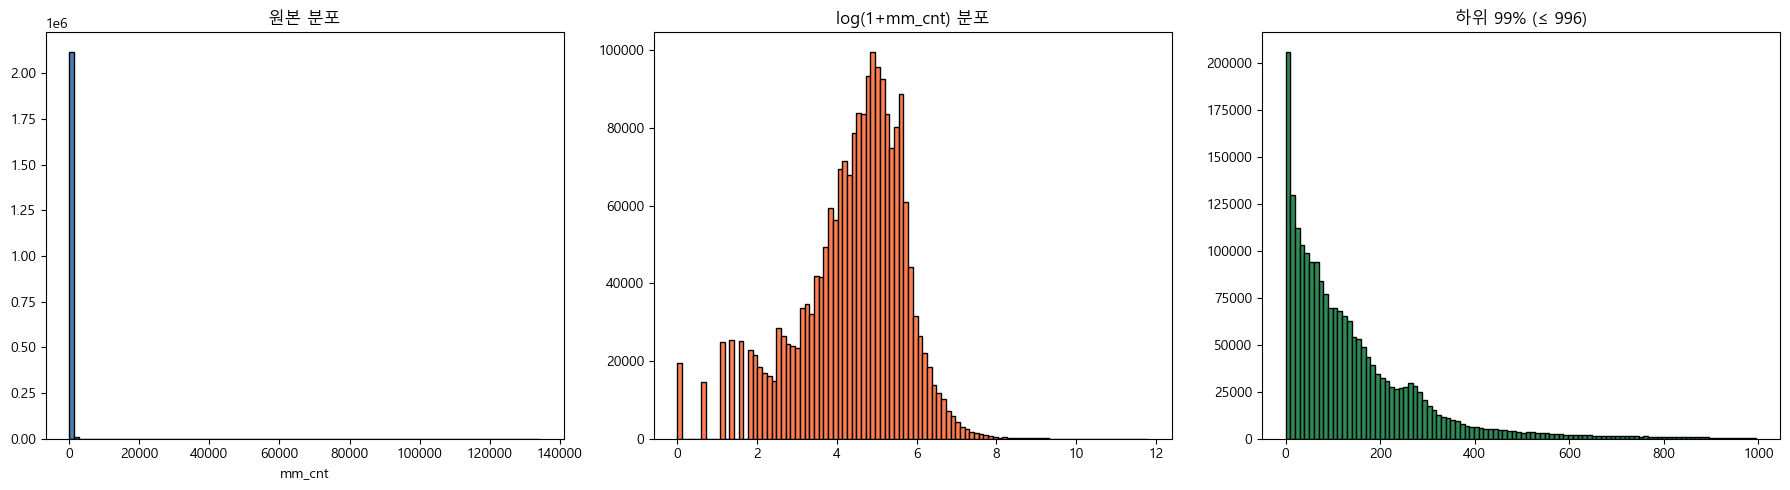

In [81]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

mm = df['mm_cnt']

# 구간별 분포
bins = [0, 12, 36, 60, 120, 240, 600, 1200, 12000, 200000]
labels = ['~1년', '1~3년', '3~5년', '5~10년', '10~20년', 
          '20~50년', '50~100년', '100~1000년', '1000년~']
dist = pd.cut(mm, bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()
print("구간별 분포:")
print(pd.DataFrame({'건수': dist, '비율(%)': (dist/len(mm)*100).round(4)}))

# 극단값
print(f"\n1000개월(약 83년) 초과: {(mm > 1000).sum():,}건")
print(f"12000개월(1000년) 초과: {(mm > 12000).sum():,}건")
print(f"\n상위 20개 값:")
print(mm.nlargest(20).values)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(mm, bins=100, color='steelblue', edgecolor='black')
axes[0].set_title('원본 분포')
axes[0].set_xlabel('mm_cnt')

axes[1].hist(np.log1p(mm), bins=100, color='coral', edgecolor='black')
axes[1].set_title('log(1+mm_cnt) 분포')

q99 = mm.quantile(0.99)
axes[2].hist(mm[mm <= q99], bins=100, color='seagreen', edgecolor='black')
axes[2].set_title(f'하위 99% (≤ {q99:,.0f})')

plt.tight_layout()
plt.show()

#### 영업개월수(최댓값 확인)

In [82]:
max_val = pd.to_numeric(df['mm_cnt'], errors='coerce').max()
print(f"최댓값: {max_val:,.0f}")

# 최댓값에 해당하는 행 전체 출력
df[df['mm_cnt'] == max_val]

최댓값: 134,368


,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
2110290,2025-12-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,134368,633,633,0,366,1,65,51,54,36,122,295


In [83]:
# blk_cd는 문자열로 변환되어 있으므로 문자열로 비교
mask_no_sale = (
    (df['blk_cd'] == '424505') &
    (df['card_tpbuz_cd'] == 'F06')
)
df[mask_no_sale].sort_values('mm_cnt', ascending=False).head(20)

,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
2110290,2025-12-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,134368,633,633,0,366,1,65,51,54,36,122,295
2048928,2025-11-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,132248,632,632,0,366,3,66,49,54,37,127,289
1989081,2025-10-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,130120,630,630,0,365,2,64,52,52,49,115,288
1929268,2025-09-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,127860,613,613,0,351,1,48,51,54,58,110,282
1868235,2025-08-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,125804,588,588,0,332,1,35,50,47,70,101,275
1805823,2025-07-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,123844,588,588,0,337,2,40,51,41,96,78,272
1745009,2025-06-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,121876,582,582,0,337,1,40,49,42,98,74,269
1685647,2025-05-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,89946,580,580,0,334,3,39,55,35,107,70,264
1626743,2025-04-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,88482,579,579,0,334,1,50,61,17,116,62,263
1567897,2025-03-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,87018,573,573,0,326,2,54,53,19,117,64,256


#### 1.2.10 가맹점수

In [84]:
col = df['mer_cnt']
Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
IQR = Q3 - Q1

print(f"NULL 수: {col.isnull().sum()}건")
print(f"음수 값: {len(col[col < 0])}건")
print(col.describe())

NULL 수: 0건
음수 값: 0건
count   2,130,071.0
mean            1.8
std             6.3
min             0.0
25%             1.0
50%             1.0
75%             2.0
max         1,207.0
Name: mer_cnt, dtype: float64


#### 가맹점수(최댓값 확인)

In [85]:
max_val = pd.to_numeric(df['mer_cnt'], errors='coerce').max()
print(f"최댓값: {max_val:,.0f}")

# 최댓값에 해당하는 행 전체 출력
df[df['mer_cnt'] == max_val]

최댓값: 1,207


,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
2070796,2025-12-01,41135,41135580,120357,U01,미디어/통신,인터넷쇼핑,E,100820,1207,595,25,917,5,59,92,115,31,196,147


#### 1.2.11 프랜차이즈 가맹점수

In [86]:
col = df['fran_cnt']

print(f"NULL 수: {col.isnull().sum()}건")
print(f"음수 값: {len(col[col < 0])}건")
print(f"프랜차이즈 수 > 가맹점 수 오류: {len(df[df['fran_cnt'] > df['mer_cnt']])}건")
print(col.describe())

NULL 수: 0건
음수 값: 0건
프랜차이즈 수 > 가맹점 수 오류: 0건
count   2,130,071.0
mean            0.1
std             3.2
min             0.0
25%             0.0
50%             0.0
75%             0.0
max           633.0
Name: fran_cnt, dtype: float64


#### 1.2.12 신규 가맹점수

In [87]:
col = df['open_cnt']

print(f"NULL 수: {col.isnull().sum()}건")
print(f"음수 값: {len(col[col < 0])}건")
print(f"신규 수 > 가맹점 수 오류: {len(df[df['open_cnt'] > df['mer_cnt']])}건")
print(col.describe())

NULL 수: 0건
음수 값: 0건
신규 수 > 가맹점 수 오류: 11건


count   2,130,071.0
mean            0.0
std             0.2
min             0.0
25%             0.0
50%             0.0
75%             0.0
max            58.0
Name: open_cnt, dtype: float64


In [88]:
# 오류 11건 상세 확인
error_rows = df[df['open_cnt'] > df['mer_cnt']]
error_rows[['ta_ym', 'cty_rgn_no', 'admi_cty_no', 'card_tpbuz_cd', 'mer_cnt', 'open_cnt']]

,ta_ym,cty_rgn_no,admi_cty_no,card_tpbuz_cd,mer_cnt,open_cnt
23216,2023-01-01,41133,41133660,F10,0,1
472835,2023-08-01,41131,41131570,Q08,0,1
602422,2023-11-01,41131,41131550,D08,1,2
1039405,2024-06-01,41135,41135550,O04,0,1
1145861,2024-08-01,41135,41135520,D14,0,1
1211153,2024-09-01,41133,41133670,Q02,0,1
1228023,2024-09-01,41131,41131520,F02,0,1
1478090,2025-02-01,41131,41131590,D11,2,3
1699984,2025-05-01,41131,41131640,O03,1,2
1747340,2025-06-01,41135,41135650,O03,0,1


- 가맹점수와 신규 가맹점수의 차이가 1이하인걸로 보아 컬럼 정의서에 나와있듯(신규 등록은 창업 및 가맹점주 변경에 따른 가맹점 재신청을 포함함)에 해당되는 내용으로 짐작

#### 1.2.13 휴업 가맹점수

In [89]:
col = df['stop_cnt']

print(f"NULL 수: {col.isnull().sum()}건")
print(f"음수 값: {len(col[col < 0])}건")
print(f"휴업 수 > 가맹점 수 오류: {len(df[df['stop_cnt'] > df['mer_cnt']])}건")
print(col.describe())

NULL 수: 0건
음수 값: 0건
휴업 수 > 가맹점 수 오류: 17건
count   2,130,071.0
mean            0.8
std             4.1
min             0.0
25%             0.0
50%             1.0
75%             1.0
max           917.0
Name: stop_cnt, dtype: float64


In [90]:
# 휴업 수 > 가맹점 수 오류 17건
error_rows = df[df['stop_cnt'] > df['mer_cnt']].copy()
error_rows['차이'] = error_rows['stop_cnt'] - error_rows['mer_cnt']
print(f"=== 휴업 수 > 가맹점 수 오류 ({len(error_rows)}건) ===")
display(error_rows[['ta_ym', 'cty_rgn_no', 'admi_cty_no', 'card_tpbuz_cd', 'mer_cnt', 'stop_cnt', '차이']].sort_values('차이', ascending=False))

=== 휴업 수 > 가맹점 수 오류 (17건) ===


,ta_ym,cty_rgn_no,admi_cty_no,card_tpbuz_cd,mer_cnt,stop_cnt,차이
39700,2023-01-01,41135,41135630,R03,0,1,1
270056,2023-05-01,41135,41135545,R07,0,1,1
560214,2023-10-01,41135,41135600,R01,0,1,1
1027144,2024-06-01,41135,41135520,R01,0,1,1
1145460,2024-08-01,41135,41135662,O02,0,1,1
1145861,2024-08-01,41135,41135520,D14,0,1,1
1169740,2024-08-01,41131,41131520,D16,0,1,1
1228023,2024-09-01,41131,41131520,F02,0,1,1
1269587,2024-10-01,41133,41133670,F15,0,1,1
1327686,2024-11-01,41133,41133670,D10,0,1,1


In [91]:
# 최댓값(917) 상위 20건
max_val = df['stop_cnt'].max()
print(f"=== stop_cnt 최댓값: {max_val:,.0f} ===")
display(df.nlargest(20, 'stop_cnt')[['ta_ym', 'cty_rgn_no', 'admi_cty_no', 'card_tpbuz_cd', 'mer_cnt', 'stop_cnt']])

=== stop_cnt 최댓값: 917 ===


,ta_ym,cty_rgn_no,admi_cty_no,card_tpbuz_cd,mer_cnt,stop_cnt
2070796,2025-12-01,41135,41135580,U01,1207,917
2010660,2025-11-01,41135,41135580,U01,1182,915
1951139,2025-10-01,41135,41135580,U01,1174,889
1890869,2025-09-01,41135,41135580,U01,1144,875
1828172,2025-08-01,41135,41135580,U01,1130,872
1766685,2025-07-01,41135,41135580,U01,1125,861
1648014,2025-05-01,41135,41135580,U01,1108,859
1589362,2025-04-01,41135,41135580,U01,1103,858
1707080,2025-06-01,41135,41135580,U01,1115,856
1530135,2025-03-01,41135,41135580,U01,1097,843


#### 1.2.14 폐업 가맹점수

In [92]:
col = df['close_cnt']

print(f"NULL 수: {col.isnull().sum()}건")
print(f"음수 값: {len(col[col < 0])}건")
print(f"폐업 수 > 가맹점 수 오류: {len(df[df['close_cnt'] > df['mer_cnt']])}건")
print(col.describe())

NULL 수: 0건
음수 값: 0건
폐업 수 > 가맹점 수 오류: 6203건
count   2,130,071.0
mean            0.0
std             0.1
min             0.0
25%             0.0
50%             0.0
75%             0.0
max            44.0
Name: close_cnt, dtype: float64


#### 1.2.15 가맹점수 영업 미만 컬럼

In [93]:
open_cols = ['open_11_cnt', 'open_12_23_cnt', 'open_24_35_cnt',
             'open_36_47_cnt', 'open_48_59_cnt', 'open_60_cnt']

for col_name in open_cols:
    s = df[col_name]
    print(f"[{col_name}] NULL: {s.isnull().sum()}건 | 음수: {(s < 0).sum()}건 | max: {s.max():,.0f} | mean: {s.mean():.2f}")

[open_11_cnt] NULL: 0건 | 음수: 0건 | max: 163 | mean: 0.23
[open_12_23_cnt] NULL: 0건 | 음수: 0건 | max: 198 | mean: 0.20
[open_24_35_cnt] NULL: 0건 | 음수: 0건 | max: 200 | mean: 0.17
[open_36_47_cnt] NULL: 0건 | 음수: 0건 | max: 198 | mean: 0.15
[open_48_59_cnt] NULL: 0건 | 음수: 0건 | max: 196 | mean: 0.13
[open_60_cnt] NULL: 0건 | 음수: 0건 | max: 295 | mean: 0.86


#### 최종 결측치 존재 컬럼

In [94]:
df.isna().sum()

ta_ym              0
cty_rgn_no         0
admi_cty_no        0
blk_cd             0
card_tpbuz_cd      0
card_tpbuz_nm_1    0
card_tpbuz_nm_2    0
sale               0
mm_cnt             0
mer_cnt            0
fran_cnt           0
open_cnt           0
stop_cnt           0
close_cnt          0
open_11_cnt        0
open_12_23_cnt     0
open_24_35_cnt     0
open_36_47_cnt     0
open_48_59_cnt     0
open_60_cnt        0
dtype: int64

In [95]:
import pandas as pd

# 집계 컬럼 리스트 (명세서의 숫자형 집계 컬럼)
count_cols = [
    'mm_cnt',         # 영업개월수 합계
    'mer_cnt',        # 가맹점수 합계
    'fran_cnt',       # 프랜차이즈 가맹점수 합계
    'open_cnt',       # 신규 가맹점수 합계
    'stop_cnt',       # 휴업 가맹점수 합계
    'close_cnt',      # 폐업 가맹점수 합계
    'open_11_cnt',    # 1년 미만
    'open_12_23_cnt', # 1~2년 미만
    'open_24_35_cnt', # 2~3년 미만
    'open_36_47_cnt', # 3~4년 미만
    'open_48_59_cnt', # 4~5년 미만
    'open_60_cnt',    # 5년 이상
]

# 식별 컬럼 (어떤 행인지 보여주는 키 컬럼들)
key_cols = ['ta_ym', 'cty_rgn_no', 'admi_cty_no', 'blk_cd', 
            'card_tpbuz_cd', 'card_tpbuz_nm_1', 'card_tpbuz_nm_2', 'sale']

# mm_cnt는 문자열로 저장되어 있을 수 있으니 숫자로 변환
df['mm_cnt_num'] = pd.to_numeric(df['mm_cnt'], errors='coerce')

# 1. 각 집계 컬럼의 최댓값 요약 테이블
print("=" * 80)
print("집계 컬럼별 최댓값 요약")
print("=" * 80)

summary_rows = []
for col in count_cols:
    # mm_cnt는 변환한 컬럼 사용
    target_col = 'mm_cnt_num' if col == 'mm_cnt' else col
    
    max_val = df[target_col].max()
    max_idx = df[target_col].idxmax()
    row = df.loc[max_idx]
    
    summary_rows.append({
        '컬럼': col,
        '최댓값': max_val,
        'ta_ym': row['ta_ym'],
        'admi_cty_no': row['admi_cty_no'],
        'blk_cd': row['blk_cd'],
        '업종(중분류)': row['card_tpbuz_nm_2'],
        'sale': row['sale'],
        'mer_cnt': row['mer_cnt'],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# 2. 각 컬럼별 최댓값 행의 전체 데이터 (상세 확인용)
print("\n" + "=" * 80)
print("집계 컬럼별 최댓값 행 상세")
print("=" * 80)

for col in count_cols:
    target_col = 'mm_cnt_num' if col == 'mm_cnt' else col
    max_val = df[target_col].max()
    
    # 최댓값과 동일한 값을 가진 행이 여러 개일 수 있으므로 전체 출력
    max_rows = df[df[target_col] == max_val]
    
    print(f"\n▶ [{col}] 최댓값: {max_val:,.0f}  (동일 최댓값 행 개수: {len(max_rows)})")
    display_cols = key_cols + count_cols
    display(max_rows[display_cols].head(5))  # 최대 5행까지만

# 3. 각 컬럼의 상위 10개 값 분포 (이상치 패턴 파악용)
print("\n" + "=" * 80)
print("각 컬럼 상위 10개 값 (이상치 여부 빠르게 확인)")
print("=" * 80)

for col in count_cols:
    target_col = 'mm_cnt_num' if col == 'mm_cnt' else col
    top10 = df[target_col].nlargest(10).reset_index(drop=True)
    print(f"\n[{col}] 상위 10개 값:")
    print(top10.apply(lambda x: f"{x:,.0f}").to_list())

# 4. sale 구간별 각 컬럼 최댓값 (구조적 차이 재확인)
print("\n" + "=" * 80)
print("sale 구간별 각 집계 컬럼의 최댓값")
print("=" * 80)

sale_max = df.groupby(df['sale'].fillna('NaN(30억초과/미등록)'))[
    ['mm_cnt_num'] + [c for c in count_cols if c != 'mm_cnt']
].max()
sale_max = sale_max.rename(columns={'mm_cnt_num': 'mm_cnt'})
print(sale_max.to_string())

집계 컬럼별 최댓값 요약


            컬럼    최댓값      ta_ym admi_cty_no blk_cd  업종(중분류) sale  mer_cnt
        mm_cnt 134368 2025-12-01    41135657 424505 세탁/가사서비스    E      633
       mer_cnt   1207 2025-12-01    41135580 120357    인터넷쇼핑    E     1207
      fran_cnt    633 2025-12-01    41135657 424505 세탁/가사서비스    E      633
      open_cnt     58 2023-04-01    41135580 120357    인터넷쇼핑   신규       58
      stop_cnt    917 2025-12-01    41135580 120357    인터넷쇼핑    E     1207
     close_cnt     44 2024-02-01    41135657 424505    인터넷쇼핑    E      576
   open_11_cnt    163 2024-01-01    41135580 120357    인터넷쇼핑    E      869
open_12_23_cnt    198 2023-01-01    41135580 120357    인터넷쇼핑    E      710
open_24_35_cnt    200 2024-01-01    41135580 120357    인터넷쇼핑    E      869
open_36_47_cnt    198 2025-02-01    41135580 120357    인터넷쇼핑    E     1091
open_48_59_cnt    196 2025-12-01    41135580 120357    인터넷쇼핑    E     1207
   open_60_cnt    295 2025-12-01    41135657 424505 세탁/가사서비스    E      633

집계 컬럼별 최댓값 행 상세

▶ [mm_c

,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
2110290,2025-12-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,134368,633,633,0,366,1,65,51,54,36,122,295



▶ [mer_cnt] 최댓값: 1,207  (동일 최댓값 행 개수: 1)


,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
2070796,2025-12-01,41135,41135580,120357,U01,미디어/통신,인터넷쇼핑,E,100820,1207,595,25,917,5,59,92,115,31,196,147


...


▶ [open_48_59_cnt] 최댓값: 196  (동일 최댓값 행 개수: 1)


,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
2070796,2025-12-01,41135,41135580,120357,U01,미디어/통신,인터넷쇼핑,E,100820,1207,595,25,917,5,59,92,115,31,196,147



▶ [open_60_cnt] 최댓값: 295  (동일 최댓값 행 개수: 1)


,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,fran_cnt,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt
2110290,2025-12-01,41135,41135657,424505,F06,생활서비스,세탁/가사서비스,E,134368,633,633,0,366,1,65,51,54,36,122,295



각 컬럼 상위 10개 값 (이상치 여부 빠르게 확인)

[mm_cnt] 상위 10개 값:
['134,368', '132,248', '130,120', '127,860', '125,804', '123,844', '121,876', '100,820', '98,564', '96,296']

[mer_cnt] 상위 10개 값:
['1,207', '1,182', '1,174', '1,144', '1,130', '1,125', '1,115', '1,108', '1,103', '1,097']

[fran_cnt] 상위 10개 값:
['633', '632', '630', '613', '595', '595', '588', '588', '582', '580']

[open_cnt] 상위 10개 값:
['58', '48', '46', '44', '37', '34', '33', '33', '33', '30']

[stop_cnt] 상위 10개 값:
['917', '915', '889', '875', '872', '861', '859', '858', '856', '843']

[close_cnt] 상위 10개 값:
['44', '16', '15', '14', '13', '12', '12', '9', '8', '8']

[open_11_cnt] 상위 10개 값:
['163', '117', '115', '115', '115', '111', '105', '100', '100', '98']

[open_12_23_cnt] 상위 10개 값:
['198', '194', '170', '163', '163', '150', '137', '127', '127', '127']

[open_24_35_cnt] 상위 10개 값:
['200', '197', '196', '196', '184', '184', '182', '176', '172', '170']

[open_36_47_cnt] 상위 10개 값:
['198', '197', '196', '194', '184', '184', '182', '176', 

In [96]:
df.to_csv('전처리완료_카드(가맹점).csv', index=False)